In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# importing required libraries
import numpy as np
import pandas as pd
import pickle # saving and loading trained model
from os import path

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.metrics import accuracy_score # for calculating accuracy of model
from sklearn.model_selection import train_test_split # for splitting the dataset for training and testing
from sklearn.metrics import classification_report # for generating a classification report of model

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_auc_score

In [4]:
train_data = pd.read_csv('data/oasis_longitudinal.csv')

In [5]:
train_data.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [6]:
del train_data['Subject ID']
del train_data['MRI ID']

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 13 columns):
Group       373 non-null object
Visit       373 non-null int64
MR Delay    373 non-null int64
M/F         373 non-null object
Hand        373 non-null object
Age         373 non-null int64
EDUC        373 non-null int64
SES         354 non-null float64
MMSE        371 non-null float64
CDR         373 non-null float64
eTIV        373 non-null int64
nWBV        373 non-null float64
ASF         373 non-null float64
dtypes: float64(5), int64(5), object(3)
memory usage: 38.0+ KB


In [8]:
train_data = train_data.dropna()

In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 354 entries, 0 to 372
Data columns (total 13 columns):
Group       354 non-null object
Visit       354 non-null int64
MR Delay    354 non-null int64
M/F         354 non-null object
Hand        354 non-null object
Age         354 non-null int64
EDUC        354 non-null int64
SES         354 non-null float64
MMSE        354 non-null float64
CDR         354 non-null float64
eTIV        354 non-null int64
nWBV        354 non-null float64
ASF         354 non-null float64
dtypes: float64(5), int64(5), object(3)
memory usage: 38.7+ KB


In [19]:
# number of attack labels 
train_data['M/F'].value_counts()

0    204
1    150
Name: M/F, dtype: int64

In [10]:
# number of attack labels 
train_data['Group'].value_counts()

Nondemented    190
Demented       127
Converted       37
Name: Group, dtype: int64

In [20]:
# number of attack labels 
train_data['Hand'].value_counts()

0    354
Name: Hand, dtype: int64

In [11]:
train_data.to_csv('processed.csv')

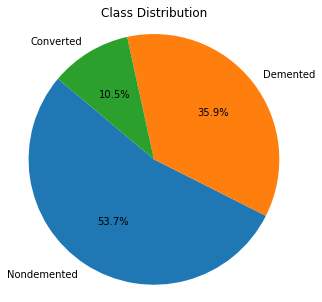

In [12]:
labels = train_data['Group'].value_counts().index
sizes = train_data['Group'].value_counts().values

plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal') 
plt.title('Class Distribution')
plt.show()

Text(0.5, 1, 'Correlation Matrix')

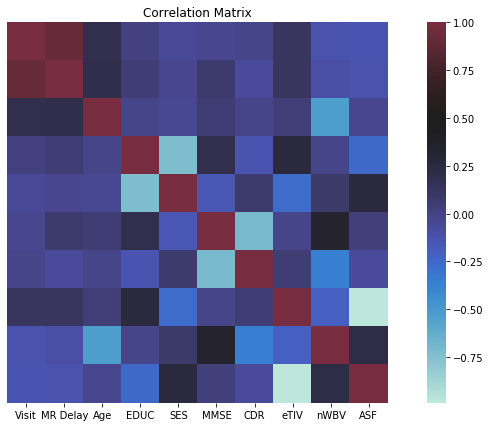

In [13]:
fig,ax=plt.subplots(1,1,figsize=(14,7))
sns.heatmap(train_data.corr(), square=True, center=0.5, yticklabels=False).set_title('Correlation Matrix')

In [14]:
# Import label encoder
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
train_data['Group']= label_encoder.fit_transform(train_data['Group'])
train_data['M/F']= label_encoder.fit_transform(train_data['M/F'])
train_data['Hand']= label_encoder.fit_transform(train_data['Hand'])

train_data['Group'].unique()
train_data['M/F'].unique()
train_data['Hand'].unique()

array([0], dtype=int64)

In [15]:
X = train_data.drop(["Group"],axis =1)
y = train_data["Group"]

In [16]:
X.columns

Index(['Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR',
       'eTIV', 'nWBV', 'ASF'],
      dtype='object')

In [17]:
# splitting the dataset 80% for training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [18]:
X_train.shape

(283, 12)

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [18]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []


#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

# NCA

In [19]:
from sklearn.neighbors import NeighborhoodComponentsAnalysis

nca = NeighborhoodComponentsAnalysis(random_state=42)
nca.fit(X, y)

NeighborhoodComponentsAnalysis(random_state=42)

# KNN

In [20]:
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model 
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X,y)

y_pred = knn.predict(X)

knn_acc = accuracy_score(y_pred, y)
knn_prec = precision_score(y_pred, y,average='weighted')
knn_rec = recall_score(y_pred, y,average='weighted')
knn_f1 = f1_score(y_pred, y,average='weighted')

In [71]:
storeResults('KNN',knn_acc,knn_prec,knn_rec,knn_f1)

In [21]:
knn_nca = KNeighborsClassifier(n_neighbors=3)
knn_nca.fit(nca.transform(X), y)

y_pred = knn_nca.predict(nca.transform(X))

knn1_acc = accuracy_score(y_pred, y)
knn1_prec = precision_score(y_pred, y,average='weighted')
knn1_rec = recall_score(y_pred, y,average='weighted')
knn1_f1 = f1_score(y_pred, y,average='weighted')

In [72]:
storeResults('KNN-NCA',knn1_acc,knn1_prec,knn1_rec,knn1_f1)

# Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
tree = DecisionTreeClassifier(random_state=10)

tree.fit(X,y)

y_pred = tree.predict(X)

dt_acc = accuracy_score(y_pred, y)
dt_prec = precision_score(y_pred, y,average='weighted')
dt_rec = recall_score(y_pred, y,average='weighted')
dt_f1 = f1_score(y_pred, y,average='weighted')

In [73]:
storeResults('Decision Tree',dt_acc,dt_prec,dt_rec,dt_f1)

In [25]:
tree_nca = DecisionTreeClassifier(random_state=10)
tree_nca.fit(nca.transform(X), y)

y_pred = tree_nca.predict(nca.transform(X))

dt1_acc = accuracy_score(y_pred, y)
dt1_prec = precision_score(y_pred, y,average='weighted')
dt1_rec = recall_score(y_pred, y,average='weighted')
dt1_f1 = f1_score(y_pred, y,average='weighted')

In [74]:
storeResults('Decision Tree - NCA',dt1_acc,dt1_prec,dt1_rec,dt1_f1)

# Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

# instantiate the model 
forest = RandomForestClassifier(max_depth=2, random_state=0)

forest.fit(X,y)

y_pred = forest.predict(X)

rf_acc = accuracy_score(y_pred, y)
rf_prec = precision_score(y_pred, y,average='weighted')
rf_rec = recall_score(y_pred, y,average='weighted')
rf_f1 = f1_score(y_pred, y,average='weighted')

In [75]:
storeResults('Random Forest',rf_acc,rf_prec,rf_rec,rf_f1)

In [28]:
forest_nca = RandomForestClassifier(max_depth=2, random_state=0)
forest_nca.fit(nca.transform(X), y)

y_pred = forest_nca.predict(nca.transform(X))

rf1_acc = accuracy_score(y_pred, y)
rf1_prec = precision_score(y_pred, y,average='weighted')
rf1_rec = recall_score(y_pred, y,average='weighted')
rf1_f1 = f1_score(y_pred, y,average='weighted')

In [76]:
storeResults('Random Forest - NCA',rf1_acc,rf1_prec,rf1_rec,rf1_f1)

# Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

# instantiate the model 
lr = LogisticRegression(random_state=0)

lr.fit(X,y)

y_pred = lr.predict(X)

lr_acc = accuracy_score(y_pred, y)
lr_prec = precision_score(y_pred, y,average='weighted')
lr_rec = recall_score(y_pred, y,average='weighted')
lr_f1 = f1_score(y_pred, y,average='weighted')

In [77]:
storeResults('Logistic Regression',lr_acc,lr_prec,lr_rec,lr_f1)

In [30]:
lr_nca = RandomForestClassifier(max_depth=2, random_state=0)
lr_nca.fit(nca.transform(X), y)

y_pred = lr_nca.predict(nca.transform(X))

lr1_acc = accuracy_score(y_pred, y)
lr1_prec = precision_score(y_pred, y,average='weighted')
lr1_rec = recall_score(y_pred, y,average='weighted')
lr1_f1 = f1_score(y_pred, y,average='weighted')

In [78]:
storeResults('Logistic Regression - NCA',lr1_acc,lr1_prec,lr1_rec,lr1_f1)

# AdaBoost

In [31]:
from sklearn.ensemble import AdaBoostClassifier

# instantiate the model 
ada = AdaBoostClassifier(n_estimators=100, random_state=0)

ada.fit(X,y)

y_pred = ada.predict(X)

ab_acc = accuracy_score(y_pred, y)
ab_prec = precision_score(y_pred, y,average='weighted')
ab_rec = recall_score(y_pred, y,average='weighted')
ab_f1 = f1_score(y_pred, y,average='weighted')

In [79]:
storeResults('AdaBoost',ab_acc,ab_prec,ab_rec,ab_f1)

In [34]:
ada_nca = AdaBoostClassifier(n_estimators=100, random_state=0)
ada_nca.fit(nca.transform(X), y)

y_pred = ada_nca.predict(nca.transform(X))

ab1_acc = accuracy_score(y_pred, y)
ab1_prec = precision_score(y_pred, y,average='weighted')
ab1_rec = recall_score(y_pred, y,average='weighted')
ab1_f1 = f1_score(y_pred, y,average='weighted')

In [80]:
storeResults('AdaBoost - NCA',ab1_acc,ab1_prec,ab1_rec,ab1_f1)

# MLP

In [33]:
from sklearn.neural_network import MLPClassifier

# instantiate the model 
mlp = MLPClassifier(random_state=1, max_iter=30)

mlp.fit(X,y)

y_pred = mlp.predict(X)

mlp_acc = accuracy_score(y_pred, y)
mlp_prec = precision_score(y_pred, y,average='weighted')
mlp_rec = recall_score(y_pred, y,average='weighted')
mlp_f1 = f1_score(y_pred, y,average='weighted')

In [81]:
storeResults('MLP',mlp_acc,mlp_prec,mlp_rec,mlp_f1)

In [35]:
mlp_nca = MLPClassifier(random_state=1, max_iter=30)
mlp_nca.fit(nca.transform(X), y)

y_pred = mlp_nca.predict(nca.transform(X))

mlp1_acc = accuracy_score(y_pred, y)
mlp1_prec = precision_score(y_pred, y,average='weighted')
mlp1_rec = recall_score(y_pred, y,average='weighted')
mlp1_f1 = f1_score(y_pred, y,average='weighted')

In [82]:
storeResults('MLP - NCA',mlp1_acc,mlp1_prec,mlp1_rec,mlp1_f1)

# Voting Classifier

In [36]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier
clf1 = AdaBoostClassifier(n_estimators=100, random_state=0)
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)

eclf1 = VotingClassifier(estimators=[('ad', clf1), ('rf', clf2)], voting='soft')
eclf1.fit(X,y)

y_pred = eclf1.predict(X)

vot_acc = accuracy_score(y_pred, y)
vot_prec = precision_score(y_pred, y,average='weighted')
vot_rec = recall_score(y_pred, y,average='weighted')
vot_f1 = f1_score(y_pred, y,average='weighted')

In [83]:
storeResults('Voting CLassifier',vot_acc,vot_prec,vot_rec,vot_f1)

In [37]:
vot_nca = VotingClassifier(estimators=[('ad', clf1), ('rf', clf2)], voting='soft')
vot_nca.fit(nca.transform(X), y)

y_pred = vot_nca.predict(nca.transform(X))

vot1_acc = accuracy_score(y_pred, y)
vot1_prec = precision_score(y_pred, y,average='weighted')
vot1_rec = recall_score(y_pred, y,average='weighted')
vot1_f1 = f1_score(y_pred, y,average='weighted')

In [84]:
storeResults('Voting CLassifier - NCA',vot1_acc,vot1_prec,vot1_rec,vot1_f1)

# Stacking Classifier

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier

estimators = [('rf', RandomForestClassifier(n_estimators=10)),('mlp', MLPClassifier(random_state=1, max_iter=30))]

clf = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=10))
clf.fit(X,y)

y_pred = clf.predict(X)

stac_acc = accuracy_score(y_pred, y)
stac_prec = precision_score(y_pred, y,average='weighted')
stac_rec = recall_score(y_pred, y,average='weighted')
stac_f1 = f1_score(y_pred, y,average='weighted')

In [85]:
storeResults('Stacking CLassifier',stac_acc,stac_prec,stac_rec,stac_f1)

In [70]:
stac_nca = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=10))
stac_nca.fit(nca.transform(X), y)

y_pred = stac_nca.predict(nca.transform(X))

stac1_acc = accuracy_score(y_pred, y)
stac1_prec = precision_score(y_pred, y,average='weighted')
stac1_rec = recall_score(y_pred, y,average='weighted')
stac1_f1 = f1_score(y_pred, y,average='weighted')

In [86]:
storeResults('Stacking CLassifier - NCA',stac1_acc,stac1_prec,stac1_rec,stac1_f1)

# DL

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D

verbose, epoch, batch_size = 1, 100, 4
activationFunction='relu'

In [61]:
X_train=X_train.values
X_test=X_test.values

X_train = X_train.reshape(-1, X_train.shape[1],1)
X_test = X_test.reshape(-1, X_test.shape[1],1)

Y_train=to_categorical(y_train)
Y_test=to_categorical(y_test)

# CNN

In [62]:
def CNN():
    
    cnnmodel = Sequential()
    cnnmodel.add(Conv1D(filters=128, kernel_size=2, activation='relu',input_shape=(X_train.shape[1],X_train.shape[2])))
    cnnmodel.add(MaxPooling1D(pool_size=2))
    cnnmodel.add(Dropout(rate=0.2))
    cnnmodel.add(Flatten())
    cnnmodel.add(Dense(3, activation='softmax'))
    cnnmodel.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
    cnnmodel.summary()
    return cnnmodel

cnnmodel = CNN()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_4 (Conv1D)            (None, 11, 128)           384       
_________________________________________________________________
max_pooling1d_4 (MaxPooling1 (None, 5, 128)            0         
_________________________________________________________________
dropout_4 (Dropout)          (None, 5, 128)            0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 640)               0         
_________________________________________________________________
dense_5 (Dense)              (None, 3)                 1923      
Total params: 2,307
Trainable params: 2,307
Non-trainable params: 0
_________________________________________________________________


In [63]:
modelhistory = cnnmodel.fit(X_train, Y_train, epochs=100, verbose=verbose, validation_split=0.2, batch_size = batch_size)

Epoch 1/100
57/57 [==============================] - 1s 3ms/step - loss: 47.2698 - accuracy: 0.3717 - val_loss: 28.5528 - val_accuracy: 0.5088
Epoch 2/100
57/57 [==============================] - 0s 1ms/step - loss: 38.7737 - accuracy: 0.4336 - val_loss: 20.3732 - val_accuracy: 0.5088
Epoch 3/100
57/57 [==============================] - 0s 2ms/step - loss: 32.6673 - accuracy: 0.4602 - val_loss: 4.3641 - val_accuracy: 0.5614
Epoch 4/100
57/57 [==============================] - 0s 2ms/step - loss: 33.8511 - accuracy: 0.4071 - val_loss: 10.9988 - val_accuracy: 0.6140
Epoch 5/100
57/57 [==============================] - 0s 1ms/step - loss: 24.9660 - accuracy: 0.4292 - val_loss: 7.1660 - val_accuracy: 0.5088
Epoch 6/100
57/57 [==============================] - 0s 1ms/step - loss: 19.6541 - accuracy: 0.4912 - val_loss: 8.5254 - val_accuracy: 0.6140
Epoch 7/100
57/57 [==============================] - 0s 1ms/step - loss: 22.6875 - accuracy: 0.4469 - val_loss: 9.6710 - val_accuracy: 0.4035
Epo

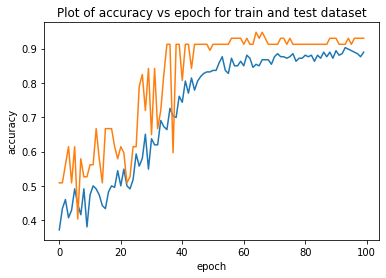

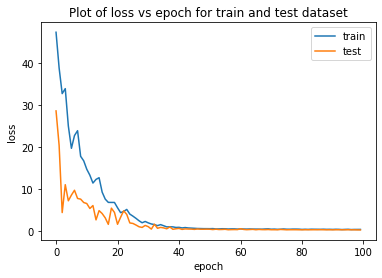

3/3 [==============================] - 0s 1ms/step


In [64]:
# Plot of accuracy vs epoch for train and test dataset
plt.plot(modelhistory.history['accuracy'])
plt.plot(modelhistory.history['val_accuracy'])
plt.title("Plot of accuracy vs epoch for train and test dataset")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

# Plot of loss vs epoch for train and test dataset
plt.plot(modelhistory.history['loss'])
plt.plot(modelhistory.history['val_loss'])
plt.title("Plot of loss vs epoch for train and test dataset")
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

cnnpredictions = cnnmodel.predict(X_test, verbose=1)
cnn_predict=np.argmax(cnnpredictions,axis=1)

y_pred = cnnmodel.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred,axis=1)

#y_prob = cnnmodel.predict_proba(X_test)[:, 1]

cnn_acc = accuracy_score(y_pred, y_test)
cnn_prec = precision_score(y_pred, y_test,average='weighted')
cnn_rec = recall_score(y_pred, y_test,average='weighted')
cnn_f1 = f1_score(y_pred, y_test,average='weighted')

In [87]:
storeResults('CNN',cnn_acc,cnn_prec,cnn_rec,cnn_f1)

# CNN + LSTM

In [65]:
import tensorflow as tf
tf.keras.backend.clear_session()

model_en = tf.keras.models.Sequential([tf.keras.layers.Conv1D(filters=64,kernel_size=5,strides=1,padding="causal",activation="relu",input_shape=(X_train.shape[1],X_train.shape[2])),
    tf.keras.layers.MaxPooling1D(pool_size=2, strides=1, padding="valid"),
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, strides=1, padding="causal", activation="relu"),
    tf.keras.layers.MaxPooling1D(pool_size=2, strides=1, padding="valid"),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(3)
])

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(5e-4,
                                                             decay_steps=1000000,
                                                             decay_rate=0.98,
                                                             staircase=False)

model_en.compile(loss=tf.keras.losses.MeanSquaredError(),
              optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.8),
              metrics=['acc'])
model_en.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 12, 64)            384       
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 11, 64)            0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 11, 32)            6176      
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 10, 32)            0         
_________________________________________________________________
lstm (LSTM)                  (None, 10, 128)           82432     
_________________________________________________________________
flatten (Flatten)            (None, 1280)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               1

In [66]:
modelhistory = model_en.fit(X_train, Y_train, epochs=100, verbose=verbose, validation_split=0.2, batch_size = batch_size)

Epoch 1/100
57/57 [==============================] - 2s 14ms/step - loss: 0.2711 - acc: 0.4558 - val_loss: 0.1954 - val_acc: 0.5088
Epoch 2/100
57/57 [==============================] - 0s 6ms/step - loss: 0.2260 - acc: 0.4823 - val_loss: 0.1987 - val_acc: 0.4912
Epoch 3/100
57/57 [==============================] - 0s 6ms/step - loss: 0.2104 - acc: 0.4912 - val_loss: 0.1875 - val_acc: 0.5088
Epoch 4/100
57/57 [==============================] - 0s 6ms/step - loss: 0.2121 - acc: 0.5487 - val_loss: 0.1958 - val_acc: 0.5088
Epoch 5/100
57/57 [==============================] - 0s 6ms/step - loss: 0.2023 - acc: 0.5531 - val_loss: 0.1904 - val_acc: 0.4737
Epoch 6/100
57/57 [==============================] - 0s 6ms/step - loss: 0.2139 - acc: 0.5398 - val_loss: 0.1931 - val_acc: 0.4737
Epoch 7/100
57/57 [==============================] - 0s 7ms/step - loss: 0.2065 - acc: 0.5265 - val_loss: 0.1880 - val_acc: 0.4737
Epoch 8/100
57/57 [==============================] - 0s 7ms/step - loss: 0.2053 - 

Epoch 63/100
57/57 [==============================] - 1s 9ms/step - loss: 0.1806 - acc: 0.6018 - val_loss: 0.1972 - val_acc: 0.4561
Epoch 64/100
57/57 [==============================] - 1s 12ms/step - loss: 0.1834 - acc: 0.5708 - val_loss: 0.1890 - val_acc: 0.4737
Epoch 65/100
57/57 [==============================] - 1s 10ms/step - loss: 0.1878 - acc: 0.5619 - val_loss: 0.1871 - val_acc: 0.4912
Epoch 66/100
57/57 [==============================] - 1s 9ms/step - loss: 0.1835 - acc: 0.5575 - val_loss: 0.1900 - val_acc: 0.4737
Epoch 67/100
57/57 [==============================] - 0s 8ms/step - loss: 0.1864 - acc: 0.5796 - val_loss: 0.1914 - val_acc: 0.4912
Epoch 68/100
57/57 [==============================] - 0s 7ms/step - loss: 0.1861 - acc: 0.5708 - val_loss: 0.1901 - val_acc: 0.5263
Epoch 69/100
57/57 [==============================] - 0s 8ms/step - loss: 0.1836 - acc: 0.5973 - val_loss: 0.1929 - val_acc: 0.5088
Epoch 70/100
57/57 [==============================] - 1s 10ms/step - loss:

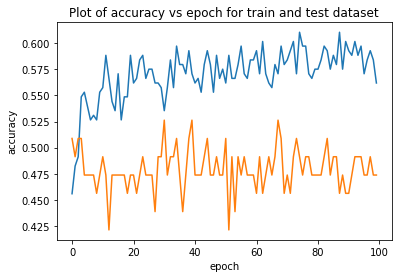

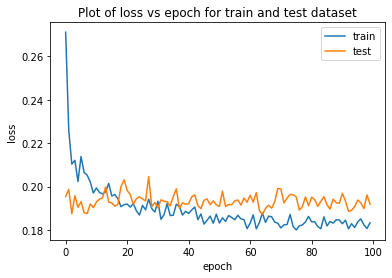

In [67]:
# Plot of accuracy vs epoch for train and test dataset
plt.plot(modelhistory.history['acc'])
plt.plot(modelhistory.history['val_acc'])
plt.title("Plot of accuracy vs epoch for train and test dataset")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

# Plot of loss vs epoch for train and test dataset
plt.plot(modelhistory.history['loss'])
plt.plot(modelhistory.history['val_loss'])
plt.title("Plot of loss vs epoch for train and test dataset")
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [68]:
y_pred = model_en.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred,axis=1)

#y_prob = cnnmodel.predict_proba(X_test)[:, 1]

ense_acc = accuracy_score(y_pred, y_test)
ense_prec = precision_score(y_pred, y_test,average='weighted')
ense_rec = recall_score(y_pred, y_test,average='weighted')
ense_f1 = f1_score(y_pred, y_test,average='weighted')

3/3 [==============================] - 0s 5ms/step


In [88]:
storeResults('CNN + LSTM',ense_acc,ense_prec,ense_rec,ense_f1)

# Comparison

In [89]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score
                      })

In [90]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.726,0.721,0.726,0.721
1,KNN-NCA,0.749,0.743,0.749,0.744
2,Decision Tree,1.000,1.000,1.000,1.000
3,Decision Tree - NCA,1.000,1.000,1.000,1.000
4,Random Forest,0.890,0.994,0.890,0.939
5,Random Forest - NCA,0.624,0.854,0.624,0.692
6,Logistic Regression,0.706,0.816,0.706,0.748
7,Logistic Regression - NCA,0.624,0.854,0.624,0.692
8,AdaBoost,0.712,0.745,0.712,0.671
9,AdaBoost - NCA,0.698,0.721,0.698,0.705


# Modelling

In [91]:
import joblib
filename = 'model1.sav'
filename1 = 'model2.sav'
joblib.dump(clf, filename)
joblib.dump(eclf1, filename1)

['model2.sav']

# Graph

In [92]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

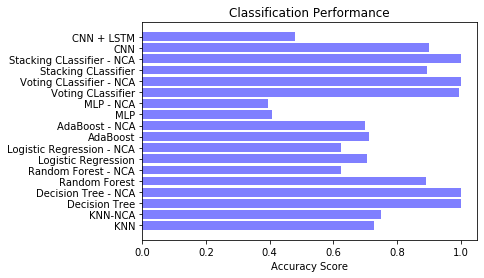

In [93]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

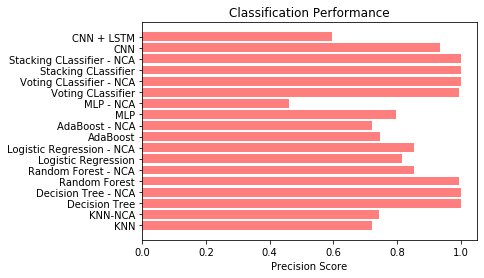

In [94]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

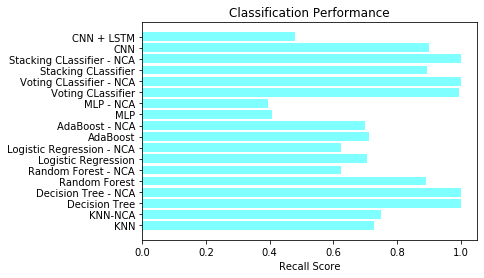

In [95]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='cyan')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

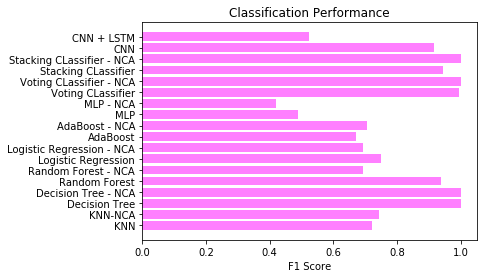

In [96]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()